In [1]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import torch.nn.functional as F

import matplotlib.pyplot as plt

In [2]:
# ============================================================
# LOAD BEST CONFIG
# ============================================================

import json

# Open the file and parse its contents
with open('descriptornet_datasetC_bho_with_Crank/best_config.json', 'r') as file:
    best_configuration = json.load(file)
best_configuration

{'depth': 3,
 'width': 128,
 'activation': 'gelu',
 'lr': 0.004622589001020831,
 'batch_size': 32,
 'weight_decay': 0.0001}

In [3]:
# ============================================================
# CONFIG
# ============================================================
DATA_DIR     = "../plga_dataset/release_dataset_even.xlsx"
NET2_WEIGHTS = "../physicsnet/physicsnet_pretrained.pt"
 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
 
# --- Network 1 (trained) ---
N1_DEPTH = best_configuration["depth"]
N1_WIDTH = best_configuration["width"]
N1_ACT   = best_configuration["activation"]


# --- Network 2 (frozen, must match pretrain_net2.py exactly) ---
N2_DEPTH = 3
N2_WIDTH = 256
N2_ACT = "silu"
 
# --- Training ---
WEIGHT_DECAY      = best_configuration['weight_decay']
# EPOCHS            = 1000
LR                = best_configuration["lr"]
BATCH_SIZE        = best_configuration["batch_size"]        # rows (particle x timepoint pairs)
N_RHO_INTEGRATION = 30
 
# --- Data ---
DESCRIPTOR_COLS = [
    'Drug MW', 'Drug TPSA', 'Drug LogP', 'Polymer MW', 'LA/GA',
    'Initial Drug-to-Polymer Ratio', 'Particle Size',
    'Drug Loading Capacity', 'Drug Encapsulation Efficiency',
    'Solubility Enhancer Concentration'
]
SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)

In [4]:
# ============================================================
# DATA LOADING
# ============================================================
def load_data(path, release_column="Crank_Release"):
    """
    Load flat table. Each row is one (particle, timepoint) pair.
    Returns flat numpy arrays ready for TensorDataset.
    Also returns per-particle arrays for D log-err evaluation.
    """
    df = pd.read_excel(path)
 
    # Unit conversions
    df['t_s']  = df['Time'] * 86400.0          # days -> seconds
    df['R_cm'] = df['Particle Size'] / 2.0 / 1e4  # diameter um -> radius cm
 
    # Flat arrays (one row per particle x timepoint)
    X = df[DESCRIPTOR_COLS].values.astype(float)   # (N_rows, n_desc)
    t = df['t_s'].values.astype(float)              # (N_rows,)
    R = df['R_cm'].values.astype(float)             # (N_rows,)
    c = df[release_column].values.astype(float)    # (N_rows,)
    D = df['Crank_D'].values.astype(float) * 10**4         # (N_rows,) eval only
 
    # Per-particle arrays for D log-err evaluation
    df_part = (df[['Formulation Index', 'Crank_D', 'R_cm'] + DESCRIPTOR_COLS]
               .drop_duplicates(subset=['Formulation Index'])
               .reset_index(drop=True))
    X_part = df_part[DESCRIPTOR_COLS].values.astype(float)
    D_part = df_part['Crank_D'].values.astype(float) * 10**4
    fid    = df_part['Formulation Index'].values
 
    # Fo sanity check
    Fo_approx = D * t / R**2
    print(f"D range: [{D.min():.3e}, {D.max():.3e}] cm^2/s")
    print(f"R range: [{R.min():.3e}, {R.max():.3e}] cm")
    print(f"t range: [{t.min():.1f}, {t.max():.1f}] s")
    print(f"Fo range (approx): [{Fo_approx.min():.4f}, {Fo_approx.max():.4f}]")
    if Fo_approx.max() > 1.5:
        print(f"  WARNING: {(Fo_approx > 1.5).sum()} rows have Fo > 1.5 "
              f"(will be clamped to PhysicsNet ceiling).")
 
    return (X, t, R, c, D,
            X_part, D_part, fid)

In [5]:
# ============================================================
# NETWORKS
# ============================================================
def get_activation(name):
    return {"tanh": nn.Tanh(), "silu": nn.SiLU(), "gelu": nn.GELU()}[name.lower()]
 
 
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, depth, width, activation):
        super().__init__()
        layers = [nn.Linear(in_dim, width), get_activation(activation)]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), get_activation(activation)]
        layers.append(nn.Linear(width, out_dim))
        self.net = nn.Sequential(*layers)
 
    def forward(self, x):
        return self.net(x)
 
 
class DescriptorNet(nn.Module):
    """Network 1 (trained): descriptors -> log10(D_eff in cm^2/s)."""
    def __init__(self, n_desc, depth=N1_DEPTH, width=N1_WIDTH,
                 activation=N1_ACT, log10_D_init=-16.0):
        super().__init__()
        self.mlp = MLP(n_desc, 1, depth, width, activation)
        nn.init.constant_(self.mlp.net[-1].bias, log10_D_init)
 
    def forward(self, desc):
        return self.mlp(desc).squeeze(-1)      # (B,)
 
 
class PhysicsNet(nn.Module):
    """Network 2 (frozen): (rho, Fo) -> u(rho, Fo)."""
    def __init__(self, depth=N2_DEPTH, width=N2_WIDTH, activation=N2_ACT):
        super().__init__()
        self.mlp = MLP(2, 1, depth, width, activation)
 
    def forward(self, rho, Fo):
        x   = torch.cat([rho**2, Fo], dim=1)
        raw = self.mlp(x)
        return (1.0 - rho**2) * raw            # hard BC: u(rho=1) = 0


In [6]:
# ============================================================
# INTEGRATION
# ============================================================
def crank_release_torch(Fo, n_terms=200):
    n = torch.arange(1, n_terms + 1, device=Fo.device, dtype=Fo.dtype)
    exponent = -(n**2) * (torch.pi**2) * Fo.unsqueeze(-1)   # (B, M)
    series = torch.sum(torch.exp(exponent) / n**2, dim=-1)  # (B,)
    return 1.0 - (6.0 / torch.pi**2) * series

def integrate_release(net2, Fo, rho_grid):
    return crank_release_torch(Fo) 


def integrate_release_physicsnet(net2, Fo, rho_grid):
    """
    Compute fractional release for a batch of Fo values.
 
    Fo       : (B,)
    rho_grid : (n_rho,)
    Returns release : (B,)
    """
    B    = Fo.shape[0]
    n_rho = rho_grid.shape[0]
 
    Fo_exp  = Fo.view(B, 1).expand(B, n_rho).reshape(-1, 1)   # (B*n_rho, 1)
    rho_exp = rho_grid.view(1, n_rho).expand(B, n_rho).reshape(-1, 1)
 
    u   = net2(rho_exp, Fo_exp).view(B, n_rho)                # (B, n_rho)
    M_t = torch.trapz(u * rho_grid**2, rho_grid, dim=1)       # (B,)
 
    return torch.clamp(1.0 - 3.0 * M_t, min=0.0, max=1.0)    # (B,)

 
 
# ============================================================
# D LOG-ERR EVALUATION (per particle, not per row)
# ============================================================
@torch.no_grad()
def eval_D_logerr(net1, X_part_tensor, D_part_tensor):
    """Mean absolute log10 D error across particles."""
    net1.eval()
    # log10_D_pred = torch.clamp(net1(X_part_tensor), min=-20.0, max=-7.0)
    log10_D_pred = net1(X_part_tensor)
    log_err = torch.mean(
        torch.abs(log10_D_pred - torch.log10(D_part_tensor))
    )
    return log_err.item()

In [7]:
# ============================================================
# MAIN — instrumented for divergence diagnosis (checks 1 & 2)
# ============================================================
PROBE_EVERY = 50     # steps between per-particle force probes
TOP_K       = 3

def particle_force(log10_D_value, t_p, R_p, c_p):
    """Loss and d(loss)/d(log10_D) for ONE particle at a given log10_D."""
    log10_D = torch.tensor([log10_D_value], device=DEVICE,
                           dtype=torch.float32, requires_grad=True)
    Fo = torch.clamp((10.0 ** log10_D) * t_p / R_p**2, min=0.0, max=1.5)
    q  = crank_release_torch(Fo)
    loss = torch.mean((q - c_p) ** 2)
    loss.backward()
    return loss.item(), log10_D.grad.item()


def main():

    test_error_list = []
    print(f"Device: {DEVICE}\n")

    (X, t, R, c, D,
     X_part, D_part, fid) = load_data(DATA_DIR, release_column="Release")

    n_desc = X.shape[1]
    all_fids = np.unique(fid)
    fids_train, fids_test = train_test_split(
        all_fids, test_size=0.2, random_state=SEED)

    df_raw  = pd.read_excel(DATA_DIR)
    row_fids = df_raw['Formulation Index'].values

    train_mask = np.isin(row_fids, fids_train)
    test_mask  = np.isin(row_fids, fids_test)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X[train_mask])
    X_test_scaled  = scaler.transform(X[test_mask])

    part_train_mask = np.isin(fid, fids_train)
    part_test_mask  = np.isin(fid, fids_test)
    X_part_train = torch.tensor(scaler.transform(X_part[part_train_mask]),
                                dtype=torch.float32, device=DEVICE)
    X_part_test  = torch.tensor(scaler.transform(X_part[part_test_mask]),
                                dtype=torch.float32, device=DEVICE)
    D_part_train = torch.tensor(D_part[part_train_mask],
                                dtype=torch.float32, device=DEVICE)
    D_part_test  = torch.tensor(D_part[part_test_mask],
                                dtype=torch.float32, device=DEVICE)

    # --- NEW: per-particle row tensors for the force probe ---
    train_fids = fid[part_train_mask]                     # fid per probe row
    rows_by_fid = {}
    for f in train_fids:
        m = (row_fids == f)
        rows_by_fid[f] = (
            torch.tensor(t[m], dtype=torch.float32, device=DEVICE),
            torch.tensor(R[m], dtype=torch.float32, device=DEVICE),
            torch.tensor(c[m], dtype=torch.float32, device=DEVICE),
        )

    def make_loader(X_scaled, mask, shuffle):
        ds = TensorDataset(
            torch.tensor(X_scaled, dtype=torch.float32),
            torch.tensor(t[mask],  dtype=torch.float32),
            torch.tensor(R[mask],  dtype=torch.float32),
            torch.tensor(c[mask],  dtype=torch.float32),
        )
        return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)

    train_loader = make_loader(X_train_scaled, train_mask, shuffle=True)
    test_loader  = make_loader(X_test_scaled,  test_mask,  shuffle=False)

    log10_D_init = -10
    net1 = DescriptorNet(n_desc=n_desc, log10_D_init=log10_D_init).to(DEVICE)
    rho_grid = torch.linspace(0, 1, N_RHO_INTEGRATION, device=DEVICE)
    optimizer = torch.optim.Adam(net1.parameters(), lr=LR,
                                 weight_decay=WEIGHT_DECAY)
    print("-" * 70)

    # --- NEW: diagnostic logs ---
    diag = dict(step=[], maxD=[], minD=[], argmax_fid=[],
                loss=[], grad_norm=[],
                probe_step=[], probe_fid=[], probe_logD=[],
                probe_loss=[], probe_grad=[])
    step = 0
    nan_hit = False

    for epoch in range(EPOCHS):
        net1.train()
        epoch_loss = 0.0

        for desc_b, t_b, R_b, c_b in train_loader:
            desc_b, t_b, R_b, c_b = [x.to(DEVICE) for x in
                                     [desc_b, t_b, R_b, c_b]]
            optimizer.zero_grad()

            log10_D = net1(desc_b)                       # UNCAPPED on purpose
            D_pred  = 10.0 ** log10_D
            Fo      = torch.clamp(D_pred * t_b / R_b**2, min=0.0, max=1.5)
            release = integrate_release(None, Fo, rho_grid)
            loss    = torch.mean((release - c_b)**2)

            # ---- NEW: per-step probe over ALL train particles ----
            with torch.no_grad():
                ld_all = net1(X_part_train)              # (N_train_particles,)
                i_max  = int(torch.argmax(ld_all))
                diag["step"].append(step)
                diag["maxD"].append(ld_all.max().item())
                diag["minD"].append(ld_all.min().item())
                diag["argmax_fid"].append(int(train_fids[i_max]))
                diag["loss"].append(loss.item())

            # ---- NEW: NaN handler — dump and stop ----
            if torch.isnan(loss) or not np.isfinite(diag["maxD"][-1]):
                print(f"NaN/inf at step {step} (epoch {epoch}). Dumping diagnostics.")
                nan_hit = True
                break

            loss.backward()
            gn = torch.nn.utils.clip_grad_norm_(net1.parameters(), 1.0)
            diag["grad_norm"].append(float(gn))
            optimizer.step()
            epoch_loss += loss.item()

            # ---- NEW: per-particle force probe on current top-K ----
            if step % PROBE_EVERY == 0:
                with torch.no_grad():
                    topk = torch.topk(ld_all, TOP_K).indices.cpu().numpy()
                for i in topk:
                    f = train_fids[i]
                    t_p, R_p, c_p = rows_by_fid[f]
                    pl, pg = particle_force(ld_all[i].item(), t_p, R_p, c_p)
                    diag["probe_step"].append(step)
                    diag["probe_fid"].append(int(f))
                    diag["probe_logD"].append(ld_all[i].item())
                    diag["probe_loss"].append(pl)
                    diag["probe_grad"].append(pg)

            step += 1

        if nan_hit:
            break

        epoch_loss /= len(train_loader)
        if epoch % 10 == 0 or epoch == EPOCHS - 1:   # lighter logging
            train_D_err = eval_D_logerr(net1, X_part_train, D_part_train)
            test_D_err  = eval_D_logerr(net1, X_part_test,  D_part_test)
            print(f"epoch {epoch:5d} | train_loss {epoch_loss:.3e} | "
                  f"D log-err train {train_D_err:.4f} | test {test_D_err:.4f} | "
                  f"maxD {diag['maxD'][-1]:.2f} "
                  f"(fid {diag['argmax_fid'][-1]})")

    np.savez("divergence_diag.npz", **{k: np.array(v) for k, v in diag.items()})
    print(f"Diagnostics saved: divergence_diag.npz ({step} steps)")
    return net1, None

## With original time samples

## Train until 200 iterations

In [8]:
SEED = 0
EPOCHS = 200

# for loggin log D
log_D_max_log = []
log_D_min_log = []

torch.manual_seed(SEED)
np.random.seed(SEED)
descriptornet, physicsnet = main()

Device: cpu

D range: [7.181e-17, 2.736e-11] cm^2/s
R range: [5.765e-05, 1.478e-02] cm
t range: [0.0, 20540069.3] s
Fo range (approx): [0.0000, 1.7138]
----------------------------------------------------------------------
epoch     0 | train_loss 5.525e-02 | D log-err train 0.3435 | test 0.3910 | maxD -10.27 (fid 252)
epoch    10 | train_loss 2.136e-02 | D log-err train 0.1446 | test 0.3461 | maxD -10.67 (fid 305)
epoch    20 | train_loss 2.013e-02 | D log-err train 0.1216 | test 0.3339 | maxD -10.52 (fid 305)
epoch    30 | train_loss 1.975e-02 | D log-err train 0.1196 | test 0.3617 | maxD -10.59 (fid 305)
epoch    40 | train_loss 1.965e-02 | D log-err train 0.1704 | test 0.3922 | maxD -10.76 (fid 252)
epoch    50 | train_loss 2.001e-02 | D log-err train 0.1197 | test 0.3349 | maxD -10.61 (fid 305)
epoch    60 | train_loss 1.941e-02 | D log-err train 0.1591 | test 0.3741 | maxD -10.64 (fid 305)
epoch    70 | train_loss 1.960e-02 | D log-err train 0.1307 | test 0.3444 | maxD -10.68 (fi

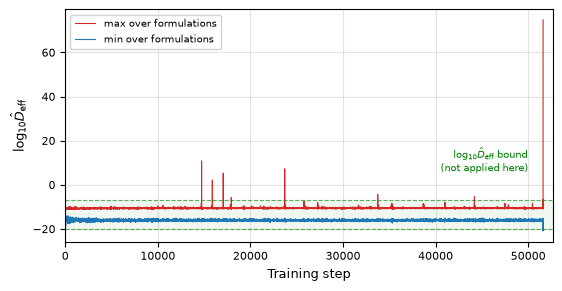

Top holders of max log10(D) [caption facts]:
  fid 305: 71.5% of steps
  fid 303: 13.6% of steps
  fid 252: 9.7% of steps
  fid 223: 3.1% of steps
Terminal step: 51608  |  final finite max: 74.8


In [23]:
d = np.load("divergence_diag.npz")
BOUND = (-20.0, -7.0)

plt.rcParams.update({'font.size': 8, 'axes.labelsize': 9})
fig, ax = plt.subplots(figsize=(5.51, 2.8), constrained_layout=True)

ax.plot(d["step"], d["maxD"], lw=0.8, color='#d62728',
        label=r"max over formulations")
ax.plot(d["step"], d["minD"], lw=0.8, color='#1f77b4',
        label=r"min over formulations")

# link to Fig. L: the bound that was NOT applied in this run
ax.axhspan(*BOUND, color='green', alpha=0.06)
for b in BOUND:
    ax.axhline(b, color='green', lw=0.8, ls='--', alpha=0.6)
ax.text(0.950, 0.35, r'log$_{10}\hat{D}_{\mathrm{eff}}$ bound' + '\n(not applied here)',
        transform=ax.transAxes, fontsize=7, ha='right', va='center',
        color='green')

ax.set_xlabel("Training step")
ax.set_ylabel(r"log$_{10}\hat{D}_{\mathrm{eff}}$")
ax.legend(fontsize=7.5, loc="upper left", framealpha=0.9)
ax.grid(True, alpha=0.35)
ax.set_xlim(0, d["step"][-1] * 1.02)

fig.savefig("../plots/fig13_diverfence_traj.pdf", dpi=500)
fig.savefig("../plots/fig13_diverfence_traj.png", dpi=500)
plt.show()

# ------------------------------------------------------------
# Caption facts (console only, not part of the figure)
# ------------------------------------------------------------
finite = np.isfinite(d["maxD"])
fids, counts = np.unique(d["argmax_fid"][finite], return_counts=True)
order = np.argsort(counts)[::-1]
print("Top holders of max log10(D) [caption facts]:")
for f, n in zip(fids[order][:4], counts[order][:4]):
    print(f"  fid {f}: {100*n/finite.sum():.1f}% of steps")
print(f"Terminal step: {d['step'][finite][-1]}  |  "
      f"final finite max: {d['maxD'][finite][-1]:.1f}")

In [10]:
finite = np.isfinite(d["maxD"])
runaway_fid = int(d["argmax_fid"][finite][-1])   # holder at last finite step
# runaway_fid = 305

print(runaway_fid)   # expect 305

223


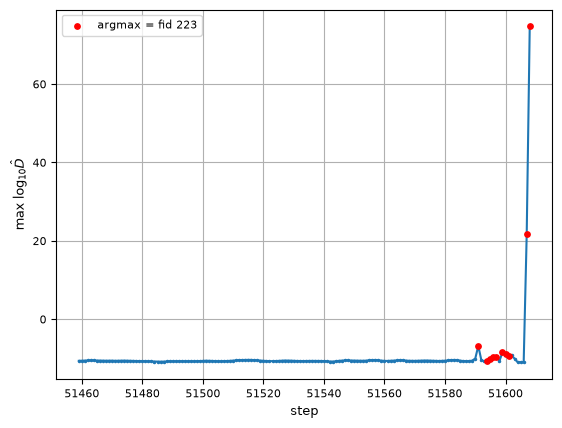

In [11]:
finite = np.isfinite(d["maxD"])
last = np.where(finite)[0][-150:]                      # final 150 finite steps
is223 = d["argmax_fid"][last] == 223
plt.plot(d["step"][last], d["maxD"][last], ".-", ms=3)
plt.scatter(d["step"][last][is223], d["maxD"][last][is223],
            color="red", s=15, zorder=5, label="argmax = fid 223")
plt.xlabel("step"); plt.ylabel("max log$_{10}\\hat{D}$"); plt.legend(); plt.grid(True)


Late-phase (last quartile of probes) for fid 223:
  mean own-loss      = 2.431e-02
  mean |own-grad|    = 8.054e-02
  log10 D range      = [-11.07, -8.89]


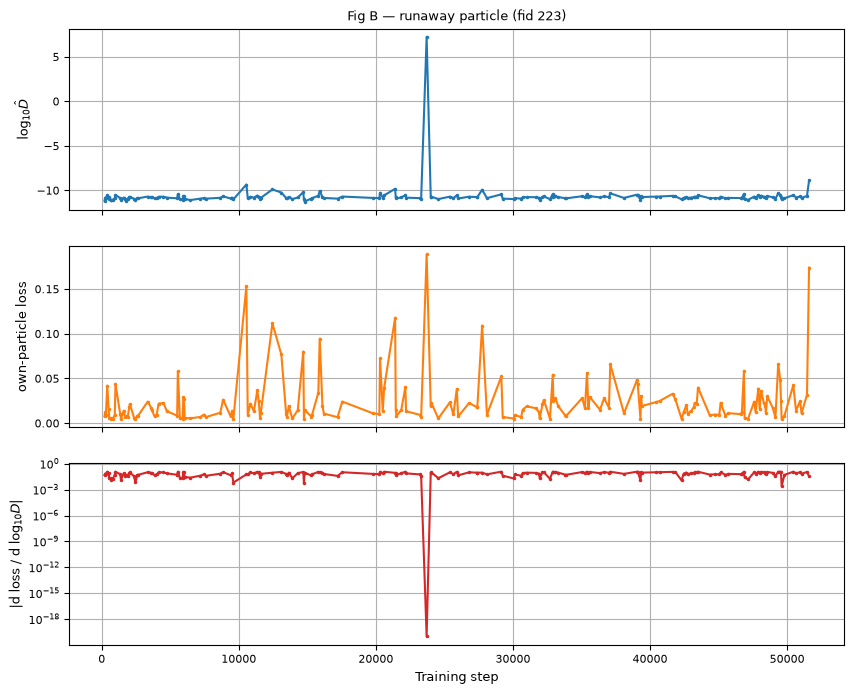

In [12]:
m = d["probe_fid"] == runaway_fid
if m.sum() == 0:
    print(f"fid {runaway_fid} never probed (wasn't in top-{3} early); "
          f"available probed fids: {np.unique(d['probe_fid'])}")
else:
    ps, plogD = d["probe_step"][m], d["probe_logD"][m]
    ploss, pgrad = d["probe_loss"][m], d["probe_grad"][m]

    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

    axes[0].plot(ps, plogD, ".-", ms=3)
    axes[0].set_ylabel(r"log$_{10}\hat{D}$")
    axes[0].set_title(f"Fig B — runaway particle (fid {runaway_fid})")

    # axes[1].semilogy(ps, np.maximum(ploss, 1e-12), ".-", ms=3, color="tab:orange")
    axes[1].plot(ps, np.maximum(ploss, 1e-12), ".-", ms=3, color="tab:orange")
    axes[1].set_ylabel("own-particle loss")

    axes[2].semilogy(ps, np.maximum(np.abs(pgrad), 1e-20), ".-", ms=3, color="tab:red")
    axes[2].set_ylabel(r"|d loss / d log$_{10}D$|")
    axes[2].set_xlabel("Training step")

    for ax in axes: ax.grid(True)

    # the mechanism's verdict, quantified:
    late = ps > np.percentile(ps, 75)
    print(f"\nLate-phase (last quartile of probes) for fid {runaway_fid}:")
    print(f"  mean own-loss      = {ploss[late].mean():.3e}")
    print(f"  mean |own-grad|    = {np.abs(pgrad[late]).mean():.3e}")
    print(f"  log10 D range      = [{plogD[late].min():.2f}, {plogD[late].max():.2f}]")

In [16]:
# ============================================================
# LOSS-LANDSCAPE SWEEP — own-particle loss vs log10(D)
# for the escaping formulations, Crank vs PhysicsNet
# ============================================================
import numpy as np, torch, pandas as pd
import matplotlib.pyplot as plt

SWEEP_FIDS = [223, 305]          # fatal escaper + chronic top-holder
LOGD_GRID  = np.linspace(-16.0, -2.0, 400)

# --- rebuild per-particle rows (same as in main) ---
(X, t, R, c, D, X_part, D_part, fid) = load_data(DATA_DIR, release_column="Release")
df_raw   = pd.read_excel(DATA_DIR)
row_fids = df_raw['Formulation Index'].values

def particle_rows(f):
    m = (row_fids == f)
    return (torch.tensor(t[m], dtype=torch.float32, device=DEVICE),
            torch.tensor(R[m], dtype=torch.float32, device=DEVICE),
            torch.tensor(c[m], dtype=torch.float32, device=DEVICE))

# --- load frozen PhysicsNet ---
net2 = PhysicsNet().to(DEVICE)
net2.load_state_dict(torch.load(NET2_WEIGHTS, map_location=DEVICE))
net2.eval()
rho_grid = torch.linspace(0, 1, N_RHO_INTEGRATION, device=DEVICE)

D range: [7.181e-17, 2.736e-11] cm^2/s
R range: [5.765e-05, 1.478e-02] cm
t range: [0.0, 20540069.3] s
Fo range (approx): [0.0000, 1.7138]


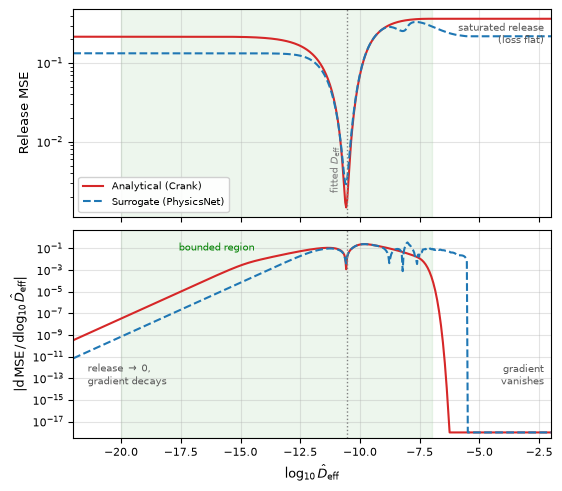

In [21]:
def particle_rows(f):
    m = (row_fids == f)
    return (torch.tensor(t[m], dtype=torch.float32, device=DEVICE),
            torch.tensor(R[m], dtype=torch.float32, device=DEVICE),
            torch.tensor(c[m], dtype=torch.float32, device=DEVICE))


# ============================================================
# FIGURE L: loss and gradient landscape of the inverse problem
# (forward models WITHOUT the Fo clip — intrinsic behavior)
# ============================================================
FID       = 305
LOGD_GRID = np.linspace(-22.0, -2.0, 500)
BOUND     = (-20.0, -7.0)
GRAD_FLOOR = 1e-18                       # display floor, stated in caption

t_p, R_p, c_p = particle_rows(FID)

@torch.no_grad()
def sweep_loss(fn):
    out = []
    for ld in LOGD_GRID:
        Fo = torch.clamp((10.0**float(ld)) * t_p / R_p**2, min=0.0)
        out.append(torch.mean((fn(net2, Fo, rho_grid) - c_p)**2).item())
    return np.array(out)

def sweep_grad(fn):
    out = []
    for ld in LOGD_GRID:
        ldt = torch.tensor([float(ld)], device=DEVICE, dtype=torch.float32,
                           requires_grad=True)
        Fo = torch.clamp((10.0**ldt) * t_p / R_p**2, min=0.0)
        loss = torch.mean((fn(net2, Fo, rho_grid) - c_p)**2)
        loss.backward()
        out.append(abs(ldt.grad.item()))
    return np.array(out)

models = [("Analytical (Crank)",     integrate_release,
           dict(color='#d62728', lw=1.5)),
          ("Surrogate (PhysicsNet)", integrate_release_physicsnet,
           dict(color='#1f77b4', lw=1.5, ls='--'))]

plt.rcParams.update({'font.size': 8, 'axes.labelsize': 9})
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5.51, 4.8), sharex=True,
                               constrained_layout=True)

for name, fn, st in models:
    ax1.semilogy(LOGD_GRID, sweep_loss(fn), label=name, **st)
    ax2.semilogy(LOGD_GRID, np.maximum(sweep_grad(fn), GRAD_FLOOR), **st)

d_fit = float(np.log10(D_part[fid == FID][0]))
for ax in (ax1, ax2):
    ax.axvspan(*BOUND, color='green', alpha=0.07)
    ax.axvline(d_fit, color='gray', ls=':', lw=1.0)
    ax.grid(True, alpha=0.35)
    ax.set_xlim(LOGD_GRID[0], LOGD_GRID[-1])

ax2.set_ylim(GRAD_FLOOR / 3, 5)          # floor sits just below axis label ticks

ax1.set_ylabel('Release MSE')
ax2.set_ylabel(r'$|\mathrm{d\,MSE} \,/\, \mathrm{d}\log_{10}\hat{D}_{\mathrm{eff}}|$')
ax2.set_xlabel(r'$\log_{10}\hat{D}_{\mathrm{eff}}$')
ax1.legend(fontsize=7.5, loc='lower left', framealpha=0.9)

# --- annotations (axes-fraction coords: immune to data rescaling) ---
ax1.text(0.985, 0.94, 'saturated release\n(loss flat)', transform=ax1.transAxes,
         fontsize=7, ha='right', va='top', color='0.35')
ax2.text(0.985, 0.30, 'gradient\nvanishes', transform=ax2.transAxes,
         fontsize=7, ha='right', va='center', color='0.35')
ax2.text(0.03, 0.30, 'release $\\to$ 0,\ngradient decays', transform=ax2.transAxes,
         fontsize=7, ha='left', va='center', color='0.35')
ax2.text(0.30, 0.94, 'bounded region', transform=ax2.transAxes,
         fontsize=7, ha='center', va='top', color='green')
# fitted-D marker label: inside top panel, left of the line, no collision
ax1.text(d_fit - 0.25, ax1.get_ylim()[0] * 2.0, 'fitted $D_{\\mathrm{eff}}$',
         fontsize=7, rotation=90, ha='right', va='bottom', color='gray')

fig.savefig("../plots/fig12_loss_gradient_landscape.pdf", dpi=500)
fig.savefig("../plots/fig12_loss_gradient_landscape.png", dpi=500)
plt.show()